In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from netCDF4 import Dataset
import math

### staggered grid

In [2]:

# mom6 needs staggered grid even in cartesian coord. 
Lx = 510e3  # m
Ly = 390e3   # m
dx = 300
dy = 300
nx = int(Lx/dx)
ny = int(Ly/dy)
nxp = nx + 1  # For u-points
nyp = ny + 1  # For v-points

# Cell centers 
xh = np.linspace(dx/2, Lx - dx/2, nx)
yh = np.linspace(dy/2, Ly - dy/2, ny)

# Cell corners/edges (q-points)
xq = np.linspace(0, Lx, nxp)  # u is at eastern faces
yq = np.linspace(0, Ly, nyp)  # v is at northern faces

# Create meshgrids for computation
Xh, Yh = np.meshgrid(xh, yh)      # eta/h grid (ny, nx)
Xq, Yh_u = np.meshgrid(xq, yh)    # u grid (ny, nxp)
Xh_v, Yq = np.meshgrid(xh, yq)    # v grid (nyp, nx)

In [3]:
f = -1e-5
g = 9.81

## velocity profiles

### case of a uniform profile

In [5]:
# 3. VELOCITY FIELDS 
# u at (ny, nx+1) - eastern faces
u = np.full((ny, nx+1), 2)
# v at (ny+1, nx) - northern faces
v = np.zeros((ny+1, nx))


In [8]:
# 5. ADD Z COORDINATE
zl = 1
layer_thickness = 500.0  # meters , not clear if i need the z dimention for the one layer model
z = np.array([-250.0])   # Single layer index
# Expand fields to (zl, y, x) with proper dimensions
#h_3d = eta_t[np.newaxis, :, :]            # (1, ny, nx)
u_3d = u[np.newaxis, :, :]            # (1, ny, nxp)
v_3d = v[np.newaxis, :, :]            # (1, nyp, nx)

# 6. WRITE VELOCITY FILE (velocity_uv.nc)
nc_vel = Dataset("/scratch/nm03/ae7501/mom6_input_directories/idealized/test09/INPUT/init_vel.nc", "w", format="NETCDF4")

# Create dimensions
nc_vel.createDimension("zl", zl)
nc_vel.createDimension("yh", ny)
nc_vel.createDimension("xh", nx)
nc_vel.createDimension("yq", nyp)
nc_vel.createDimension("xq", nxp)

# Create coordinate variables (1D arrays)
zl_var = nc_vel.createVariable("zl", "f4", ("zl",))
zl_var[:] = z
zl_var.axis = "Z"
zl_var.long_name = "depth to layer"

xh_var = nc_vel.createVariable("xh", "f4", ("xh",))
xh_var[:] = xh
xh_var.axis = "X"
xh_var.long_name = "h-point longitude"
xh_var.units = "meters"

yh_var = nc_vel.createVariable("yh", "f4", ("yh",))
yh_var[:] = yh
yh_var.axis = "Y"
yh_var.long_name = "h-point latitude"
yh_var.units = "meters"

xq_var = nc_vel.createVariable("xq", "f4", ("xq",))
xq_var[:] = xq
xq_var.axis = "X"
xq_var.long_name = "q-point longitude"
xq_var.units = "meters"

yq_var = nc_vel.createVariable("yq", "f4", ("yq",))
yq_var[:] = yq
yq_var.axis = "Y"
yq_var.long_name = "q-point latitude"
yq_var.units = "meters"

# Create velocity variables
u_var = nc_vel.createVariable("u", "f4", ("zl", "yh", "xq"))
u_var[:] = u_3d
u_var.units = "m s-1"
u_var.long_name = "Eastward velocity"
u_var.standard_name = "eastward_sea_water_velocity"

v_var = nc_vel.createVariable("v", "f4", ("zl", "yq", "xh"))
v_var[:] = v_3d
v_var.units = "m s-1"
v_var.long_name = "Northward velocity"
v_var.standard_name = "northward_sea_water_velocity"

nc_vel.regrid_method = "bilinear"
nc_vel.close()

print(f"Created velocity_uv.nc")
print(f"  u: ({zl}, {ny}, {nxp}) at (zl, yh, xq)")
print(f"  v: ({zl}, {nyp}, {nx}) at (zl, yq, xh)")

Created velocity_uv.nc
  u: (1, 400, 1001) at (zl, yh, xq)
  v: (1, 401, 1000) at (zl, yq, xh)


### case of a bickley jet

In [6]:
U = 0.20      # m/s
Ljet = 10e3  # m
y0 = Ly/2    # m

yprime_h = (Yh - y0) / Ljet      # for eta
yprime_u = (Yh_u - y0) / Ljet    # for u
yprime_v = (Yq - y0) / Ljet      # for v

# 3. VELOCITY FIELDS (Bickley Jet) ON STAGGERED GRID
# u at (ny, nx+1) - eastern faces
u = U * (1 / np.cosh(yprime_u)**2)
u_clean = u
# v at (ny+1, nx) - northern faces
v = np.zeros((ny+1, nx))

# Add small decaying noise to u
random_noise = np.random.randn(*u.shape)
decay_factor = np.exp(-  np.cosh(yprime_u)**2)
noise = 1e-2 * decay_factor * random_noise
u = u + noise

# 4. FREE SURFACE / THICKNESS FIELD
#f=2* 7.292e-5*math.sin(math.radians(-15))


In [8]:
yprime_u.shape

(400, 1001)

In [3]:
'''random_noise = np.random.randn(*v.shape)
decay_factor = np.exp(-  np.cosh(yprime_v)**2)
noise = 1e-2 * decay_factor * random_noise
v = v +noise
'''

'random_noise = np.random.randn(*v.shape)\ndecay_factor = np.exp(-  np.cosh(yprime_v)**2)\nnoise = 1e-2 * decay_factor * random_noise\nv = v +noise\n'

In [4]:
'''u_cent = U * (1 / np.cosh(yprime_h)**2)

random_noise = np.random.randn(*u_cent.shape)
decay_factor = np.exp(-  np.cosh(yprime_h)**2)
noise = 1e-4 * decay_factor * random_noise
u_cent = u_cent + noise'''

'u_cent = U * (1 / np.cosh(yprime_h)**2)\n\nrandom_noise = np.random.randn(*u_cent.shape)\ndecay_factor = np.exp(-  np.cosh(yprime_h)**2)\nnoise = 1e-4 * decay_factor * random_noise\nu_cent = u_cent + noise'

In [5]:
deta = -(U*f*Ljet)/g 
eta_t = deta* np.tanh(yprime_h)

In [6]:
deta

-0.0020387359836901123

In [7]:
u_noise = u- u_clean #hust to make sure that nosie is properly integrated to the u

In [ ]:
# PLOTTING
# Plot u
plt.figure(figsize=(10,4))
plt.title("noise (at xq, yh)")
plt.pcolormesh(Xq, Yh_u, u_noise, shading='auto')
plt.colorbar(label="m/s")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.tight_layout()
plt.show()

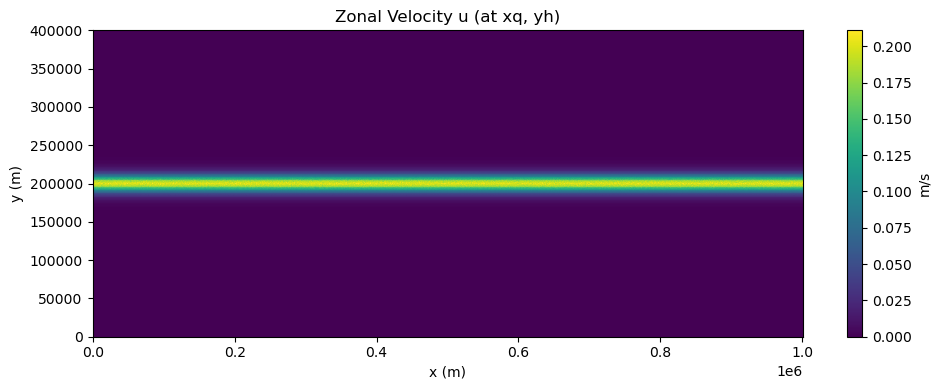

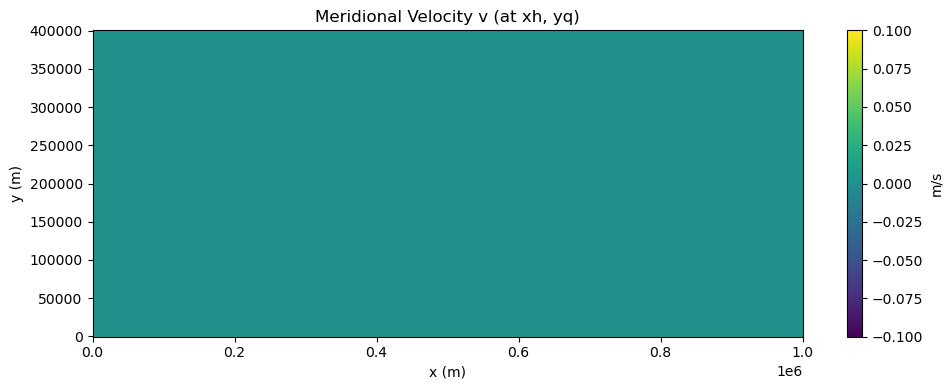

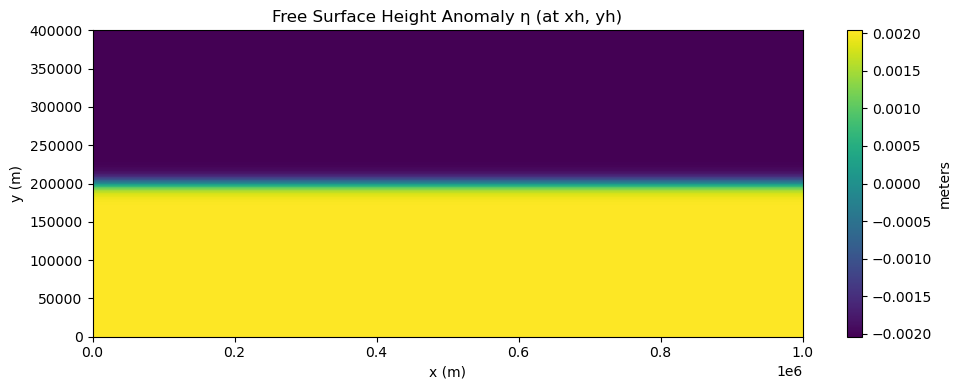

In [9]:

# PLOTTING
# Plot u
plt.figure(figsize=(10,4))
plt.title("Zonal Velocity u (at xq, yh)")
plt.pcolormesh(Xq, Yh_u, u, shading='auto')
plt.colorbar(label="m/s")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.tight_layout()
plt.show()

# Plot v
plt.figure(figsize=(10,4))
plt.title("Meridional Velocity v (at xh, yq)")
plt.pcolormesh(Xh_v, Yq, v, shading='auto')
plt.colorbar(label="m/s")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.tight_layout()
plt.show()

# Plot eta
plt.figure(figsize=(10,4))
plt.title("Free Surface Height Anomaly η (at xh, yh)")
plt.pcolormesh(xh, yh, eta_t, shading='auto')
plt.colorbar(label="meters")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.tight_layout()
plt.show()




In [21]:
# 5. ADD Z COORDINATE
zl = 1
layer_thickness = 500.0  # meters , not clear if i need the z dimention for the one layer model
z = np.array([-250.0])   # Single layer index
# Expand fields to (zl, y, x) with proper dimensions
h_3d = eta_t[np.newaxis, :, :]            # (1, ny, nx)
u_3d = u[np.newaxis, :, :]            # (1, ny, nxp)
v_3d = v[np.newaxis, :, :]            # (1, nyp, nx)

# 6. WRITE VELOCITY FILE (velocity_uv.nc)
nc_vel = Dataset("/scratch/nm03/ae7501/mom6_input_directories/idealized/test09/INPUT/init_vel.nc", "w", format="NETCDF4")

# Create dimensions
nc_vel.createDimension("zl", zl)
nc_vel.createDimension("yh", ny)
nc_vel.createDimension("xh", nx)
nc_vel.createDimension("yq", nyp)
nc_vel.createDimension("xq", nxp)

# Create coordinate variables (1D arrays)
zl_var = nc_vel.createVariable("zl", "f4", ("zl",))
zl_var[:] = z
zl_var.axis = "Z"
zl_var.long_name = "depth to layer"

xh_var = nc_vel.createVariable("xh", "f4", ("xh",))
xh_var[:] = xh
xh_var.axis = "X"
xh_var.long_name = "h-point longitude"
xh_var.units = "meters"

yh_var = nc_vel.createVariable("yh", "f4", ("yh",))
yh_var[:] = yh
yh_var.axis = "Y"
yh_var.long_name = "h-point latitude"
yh_var.units = "meters"

xq_var = nc_vel.createVariable("xq", "f4", ("xq",))
xq_var[:] = xq
xq_var.axis = "X"
xq_var.long_name = "q-point longitude"
xq_var.units = "meters"

yq_var = nc_vel.createVariable("yq", "f4", ("yq",))
yq_var[:] = yq
yq_var.axis = "Y"
yq_var.long_name = "q-point latitude"
yq_var.units = "meters"

# Create velocity variables
u_var = nc_vel.createVariable("u", "f4", ("zl", "yh", "xq"))
u_var[:] = u_3d
u_var.units = "m s-1"
u_var.long_name = "Eastward velocity"
u_var.standard_name = "eastward_sea_water_velocity"

v_var = nc_vel.createVariable("v", "f4", ("zl", "yq", "xh"))
v_var[:] = v_3d
v_var.units = "m s-1"
v_var.long_name = "Northward velocity"
v_var.standard_name = "northward_sea_water_velocity"

nc_vel.regrid_method = "bilinear"
nc_vel.close()

print(f"Created velocity_uv.nc")
print(f"  u: ({zl}, {ny}, {nxp}) at (zl, yh, xq)")
print(f"  v: ({zl}, {nyp}, {nx}) at (zl, yq, xh)")

# 7. WRITE THICKNESS FILE (thickness_h.nc)
nc_h = Dataset("/scratch/nm03/ae7501/mom6_input_directories/idealized/test06/INPUT/init_eta.nc", "w", format="NETCDF4")

# Create dimensions
nc_h.createDimension("yh", ny)
nc_h.createDimension("xh", nx)

# Create coordinate variables (1D arrays)
xh_var2 = nc_h.createVariable("xh", "f4", ("xh",))
xh_var2[:] = xh
xh_var2.axis = "X"
xh_var2.long_name = "h-point longitude"
xh_var2.units = "meters"

yh_var2 = nc_h.createVariable("yh", "f4", ("yh",))
yh_var2[:] = yh
yh_var2.axis = "Y"
yh_var2.long_name = "h-point latitude"
yh_var2.units = "meters"

# Create thickness variable
h_var = nc_h.createVariable("eta_t", "f4", ("yh", "xh"))
h_var[:] = h_3d
h_var.units = "m"
h_var.long_name = "Layer thickness"
h_var.standard_name = "sea_floor_depth_below_sea_surface"

nc_h.close()

print(f"Created thickness_h.nc")
print(f"  h: ({ny}, {nx}) at (yh, xh)")

print("Staggered grid setup complete!")
print(f"  Grid: {nx} × {ny} cells")
print(f"  h: at cell centers (xh, yh)")
print(f"  u: at eastern faces (xq, yh)")
print(f"  v: at northern faces (xh, yq)")

Created velocity_uv.nc
  u: (1, 400, 1001) at (zl, yh, xq)
  v: (1, 401, 1000) at (zl, yq, xh)
Created thickness_h.nc
  h: (400, 1000) at (yh, xh)
Staggered grid setup complete!
  Grid: 1000 × 400 cells
  h: at cell centers (xh, yh)
  u: at eastern faces (xq, yh)
  v: at northern faces (xh, yq)


In [11]:
ic = xr.open_dataset('/scratch/nm03/ae7501/mom6_input_directories/idealized/test05/INPUT/init_eta.nc')
ic

<xarray.Dataset> Size: 2MB
Dimensions:  (yh: 400, xh: 1000)
Coordinates:
  * yh       (yh) float32 2kB 500.0 1.5e+03 2.5e+03 ... 3.985e+05 3.995e+05
  * xh       (xh) float32 4kB 500.0 1.5e+03 2.5e+03 ... 9.985e+05 9.995e+05
Data variables:
    eta_t    (yh, xh) float32 2MB ...

### Case of a broken velocity profile

In [49]:
# Initialize depth array for y-axis
u = np.zeros(ny)

u[0:191] = -0.2 # (shallow_depth, deeper_Depth, no_indices_from_ny_start_to_end)

# overlap at ny=191 to ensure continuity
u[191:201] = np.linspace(-0.2, 0.2, 10)

u[201:] = 0.2

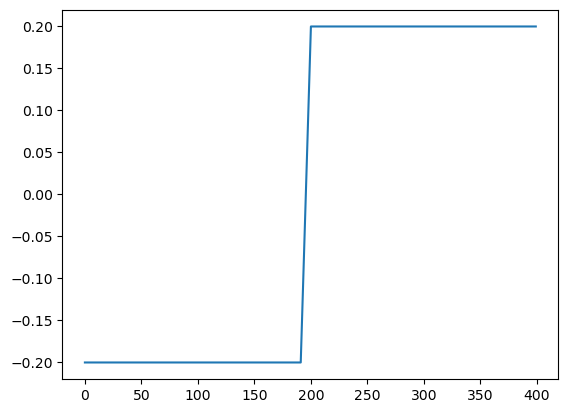

In [50]:
plt.plot(u)

Shape: (400, 1001)


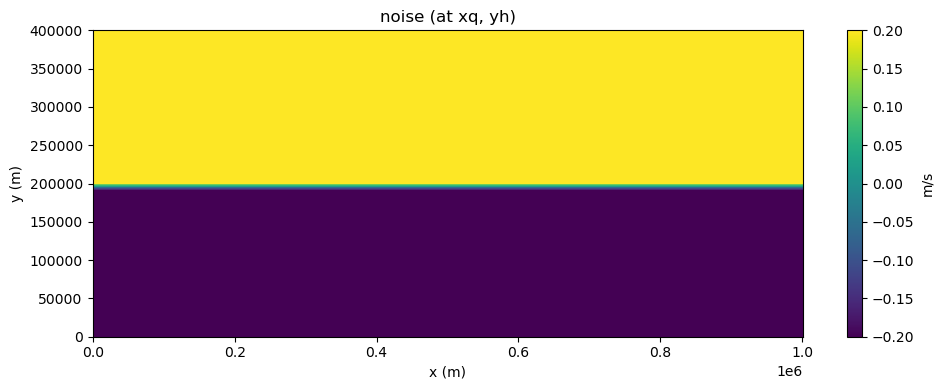

In [51]:
# Create the 2D array by repeating the Y profile across the X dimension
# Shape will be (400, 1000)
u_2d = np.tile(u[:, np.newaxis], (1, nxp))
print(f"Shape: {u_2d.shape}")
# Plot u
plt.figure(figsize=(10,4))
plt.title("noise (at xq, yh)")
plt.pcolormesh(Xq, Yh_u, u_2d, shading='auto')
plt.colorbar(label="m/s")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.tight_layout()
plt.show()

In [52]:
# Then add 2D noise
random_noise = np.random.randn(ny, nxp)  # Full 2D noise
noise_amplitude = 1e-3
# Add noise to shear region across ALL x-points
u_2d[191:201, :] = u_2d[191:201, :] + noise_amplitude * random_noise[191:201, :]

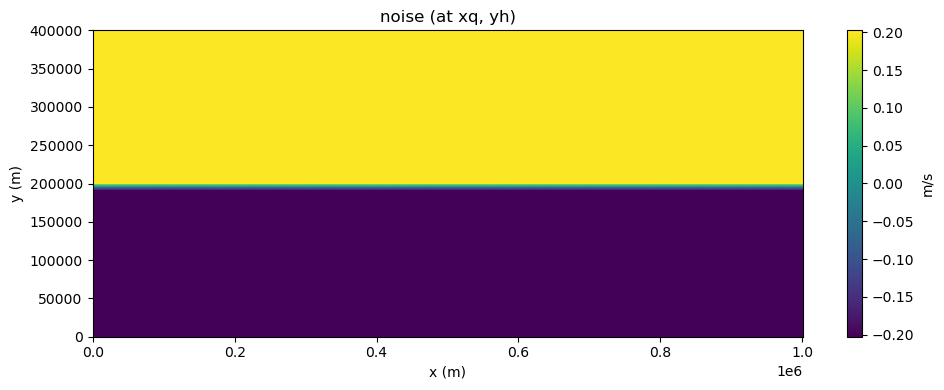

In [54]:
# Plot u
plt.figure(figsize=(10,4))
plt.title("noise (at xq, yh)")
plt.pcolormesh(Xq, Yh_u, u_2d, shading='auto')
plt.colorbar(label="m/s")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.tight_layout()
plt.show()

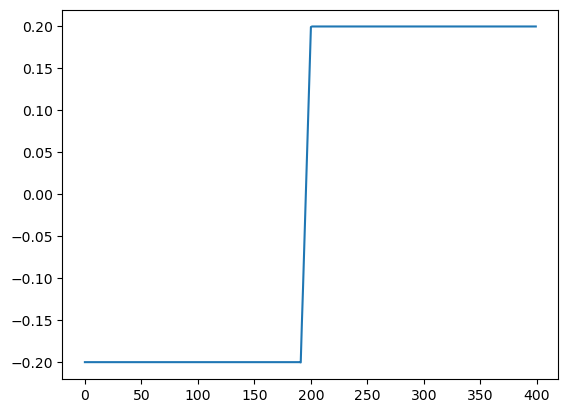

In [55]:
plt.plot(u_2d[:,0])

In [56]:
v = np.zeros((ny+1, nx))
v.shape

(401, 1000)

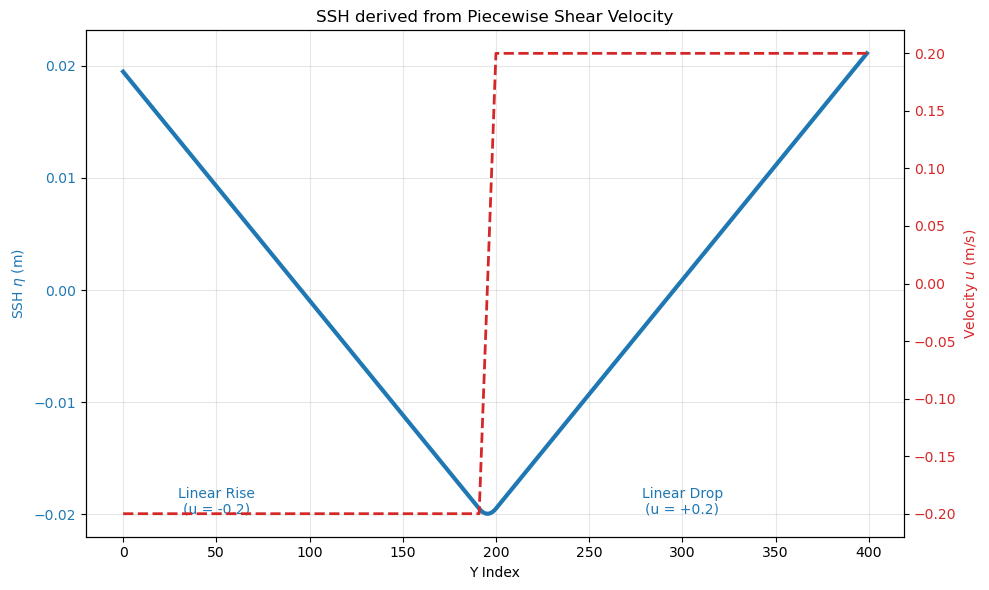

In [65]:
from scipy.integrate import cumulative_trapezoid

# 3. Calculate SSH (Eta) numerically
# Fundamental Equation: d(eta)/dy = -(f/g) * u
# Therefore: eta = Integrate[ -(f/g) * u ] dy

deta = -(f / g) *u
# We use cumulative_trapezoid to integrate along the y-axis
# initial=0 ensures the output array has the same length as the input
eta_1d_i = cumulative_trapezoid(deta, yh, initial=0)

# Optional: Center the SSH so the mean is 0 (sea level)
eta_1d = eta_1d_i - np.mean(eta_1d_i)
# 4. Create 2D arrays
#u_2d = np.tile(u[:, np.newaxis], (1, nxp))
eta_2d = np.tile(eta_1d[:, np.newaxis], (1, nx))


# ---------------------------------------------------------
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot SSH (Blue)
color = 'tab:blue'
ax1.set_xlabel('Y Index')
ax1.set_ylabel('SSH $\eta$ (m)', color=color)
ax1.plot(eta_1d, color=color, linewidth=3, label='SSH ($\eta$)')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, alpha=0.3)

# Highlight the shape
ax1.text(50, np.min(eta_1d), "Linear Rise\n(u = -0.2)", color=color, ha='center')
ax1.text(300, np.min(eta_1d), "Linear Drop\n(u = +0.2)", color=color, ha='center')

# Plot Velocity (Red)
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Velocity $u$ (m/s)', color=color)
ax2.plot(u, color=color, linestyle='--', linewidth=2, label='Velocity ($u$)')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('SSH derived from Piecewise Shear Velocity')
fig.tight_layout()
plt.show()

In [66]:
# 5. ADD Z COORDINATE
zl = 1
layer_thickness = 500.0  # meters , not clear if i need the z dimention for the one layer model
z = np.array([-250.0])   # Single layer index
# Expand fields to (zl, y, x) with proper dimensions
v_3d = v[np.newaxis, :, :]            # (1, nyp, nx)
u_3d = u_2d[np.newaxis, :, :]            # (1, ny, nxp)

# 6. WRITE VELOCITY FILE (velocity_uv.nc)
nc_vel = Dataset("/scratch/nm03/ae7501/mom6_input_directories/idealized/test07/INPUT/init_vel.nc", "w", format="NETCDF4")

# Create dimensions
nc_vel.createDimension("zl", zl)
nc_vel.createDimension("yh", ny)
nc_vel.createDimension("xh", nx)
nc_vel.createDimension("yq", nyp)
nc_vel.createDimension("xq", nxp)

# Create coordinate variables (1D arrays)
zl_var = nc_vel.createVariable("zl", "f4", ("zl",))
zl_var[:] = z
zl_var.axis = "Z"
zl_var.long_name = "depth to layer"

xh_var = nc_vel.createVariable("xh", "f4", ("xh",))
xh_var[:] = xh
xh_var.axis = "X"
xh_var.long_name = "t-point longitude"
xh_var.units = "meters"

yh_var = nc_vel.createVariable("yh", "f4", ("yh",))
yh_var[:] = yh
yh_var.axis = "Y"
yh_var.long_name = "t-point latitude"
yh_var.units = "meters"

xq_var = nc_vel.createVariable("xq", "f4", ("xq",))
xq_var[:] = xq
xq_var.axis = "X"
xq_var.long_name = "q-point longitude"
xq_var.units = "meters"

yq_var = nc_vel.createVariable("yq", "f4", ("yq",))
yq_var[:] = yq
yq_var.axis = "Y"
yq_var.long_name = "q-point latitude"
yq_var.units = "meters"

# Create velocity variables
u_var = nc_vel.createVariable("u", "f4", ("zl", "yh", "xq"))
u_var[:] = u_3d
u_var.units = "m s-1"
u_var.long_name = "Eastward velocity"
u_var.standard_name = "eastward_sea_water_velocity"

v_var = nc_vel.createVariable("v", "f4", ("zl", "yq", "xh"))
v_var[:] = v_3d
v_var.units = "m s-1"
v_var.long_name = "Northward velocity"
v_var.standard_name = "northward_sea_water_velocity"

nc_vel.regrid_method = "bilinear"
nc_vel.close()

In [67]:
eta_2d.shape

(400, 1000)

In [68]:
h_3d = eta_2d[np.newaxis, :, :]            # (1, ny, nx)

# 7.SSH  FILE (.nc)
nc_h = Dataset("/scratch/nm03/ae7501/mom6_input_directories/idealized/test07/INPUT/init_eta.nc", "w", format="NETCDF4")

# Create dimensions
nc_h.createDimension("yh", ny)
nc_h.createDimension("xh", nx)

# Create coordinate variables (1D arrays)
xh_var2 = nc_h.createVariable("xh", "f4", ("xh",))
xh_var2[:] = xh
xh_var2.axis = "X"
xh_var2.long_name = "t-point longitude"
xh_var2.units = "meters"

yh_var2 = nc_h.createVariable("yh", "f4", ("yh",))
yh_var2[:] = yh
yh_var2.axis = "Y"
yh_var2.long_name = "t-point latitude"
yh_var2.units = "meters"

# Create thickness variable
h_var = nc_h.createVariable("eta_t", "f4", ("yh", "xh"))
h_var[:] = h_3d
h_var.units = "m"
h_var.long_name = "Layer thickness"
h_var.standard_name = "sea_floor_depth_below_sea_surface"

nc_h.close()

print(f"Created thickness_h.nc")
print(f"  h: ({ny}, {nx}) at (yh, xh)")

print("Staggered grid setup complete!")
print(f"  Grid: {nx} × {ny} cells")
print(f"  h: at cell centers (xh, yh)")
print(f"  u: at eastern faces (xq, yh)")
print(f"  v: at northern faces (xh, yq)")

Created thickness_h.nc
  h: (400, 1000) at (yh, xh)
Staggered grid setup complete!
  Grid: 1000 × 400 cells
  h: at cell centers (xh, yh)
  u: at eastern faces (xq, yh)
  v: at northern faces (xh, yq)


### case of a tanh profile

In [31]:
U = 0.20      # m/s
Ljet = 10e3  # m
y0 = Ly/2    # m

yprime_h = (Yh - y0) / Ljet      # for eta
yprime_u = (Yh_u - y0) / Ljet    # for u
yprime_v = (Yq - y0) / Ljet      # for v

# 3. VELOCITY FIELDS (Bickley Jet) ON STAGGERED GRID
# u at (ny, nx+1) - eastern faces
u = U * np.tanh(yprime_u)

u_clean = u
# v at (ny+1, nx) - northern faces
v = np.zeros((ny+1, nx))

# Add small decaying noise to u
random_noise = np.random.randn(*u.shape)
decay_factor = 1 / np.cosh(yprime_u)**2   # sech^2
noise = 1e-3 * decay_factor * random_noise
u = u + noise

# 4. FREE SURFACE / THICKNESS FIELD
#f=2* 7.292e-5*math.sin(math.radians(-15))

In [32]:
u_noise = u-u_clean

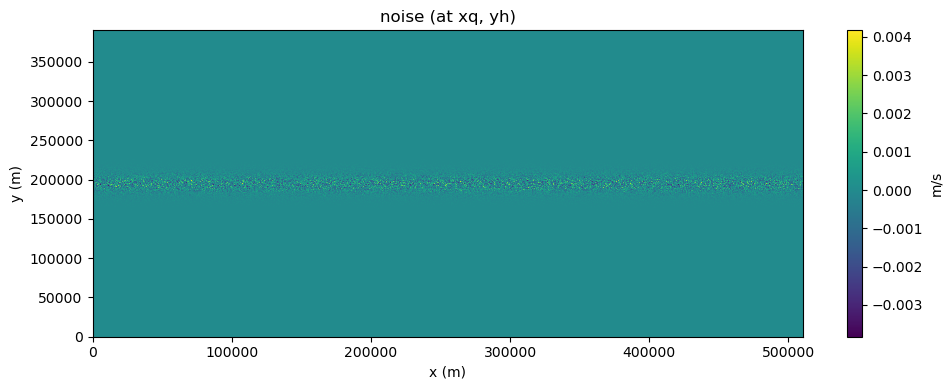

In [33]:
# PLOTTING
# Plot u
plt.figure(figsize=(10,4))
plt.title("noise (at xq, yh)")
plt.pcolormesh(Xq, Yh_u, u_noise, shading='auto')
plt.colorbar(label="m/s")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.tight_layout()
plt.show()

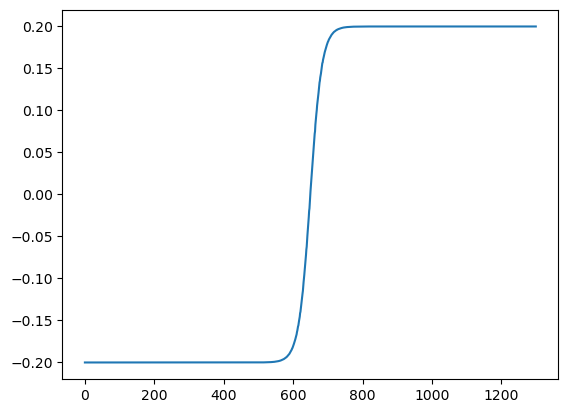

In [34]:
plt.plot(u[:,10])

In [137]:
eta_t = -(f * U * Ljet / g) * np.log(np.cosh(yprime_h))
eta_t = eta_t - eta_t.mean()


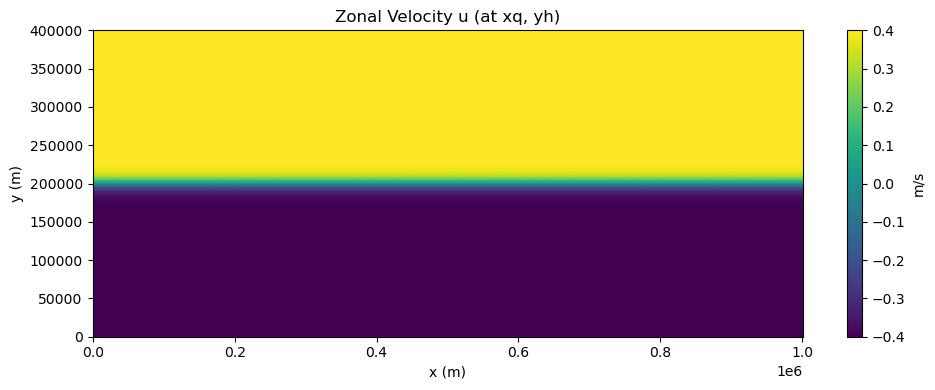

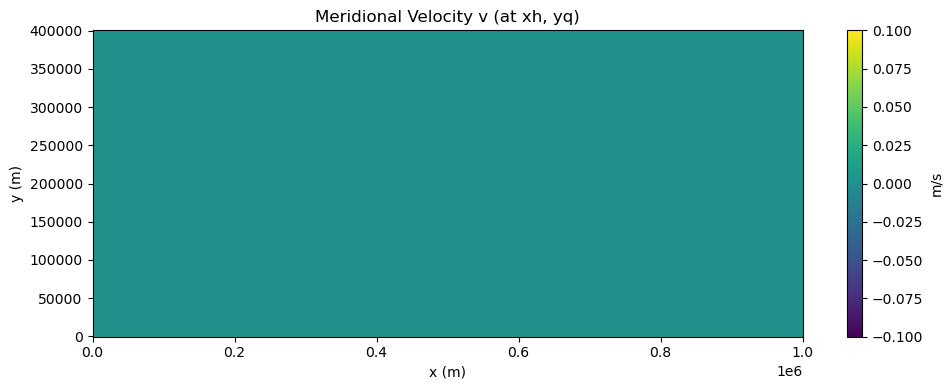

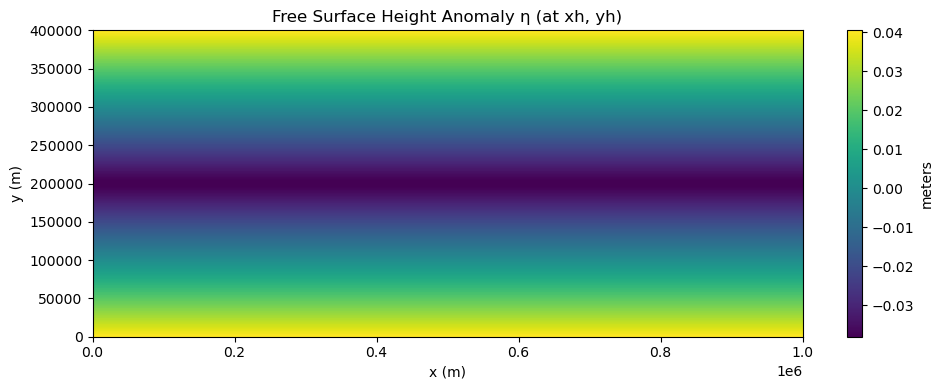

In [138]:

# PLOTTING
# Plot u
plt.figure(figsize=(10,4))
plt.title("Zonal Velocity u (at xq, yh)")
plt.pcolormesh(Xq, Yh_u, u, shading='auto')
plt.colorbar(label="m/s")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.tight_layout()
plt.show()

# Plot v
plt.figure(figsize=(10,4))
plt.title("Meridional Velocity v (at xh, yq)")
plt.pcolormesh(Xh_v, Yq, v, shading='auto')
plt.colorbar(label="m/s")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.tight_layout()
plt.show()

# Plot eta
plt.figure(figsize=(10,4))
plt.title("Free Surface Height Anomaly η (at xh, yh)")
plt.pcolormesh(xh, yh, eta_t, shading='auto')
plt.colorbar(label="meters")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.tight_layout()
plt.show()

In [139]:
u.shape

(400, 1001)

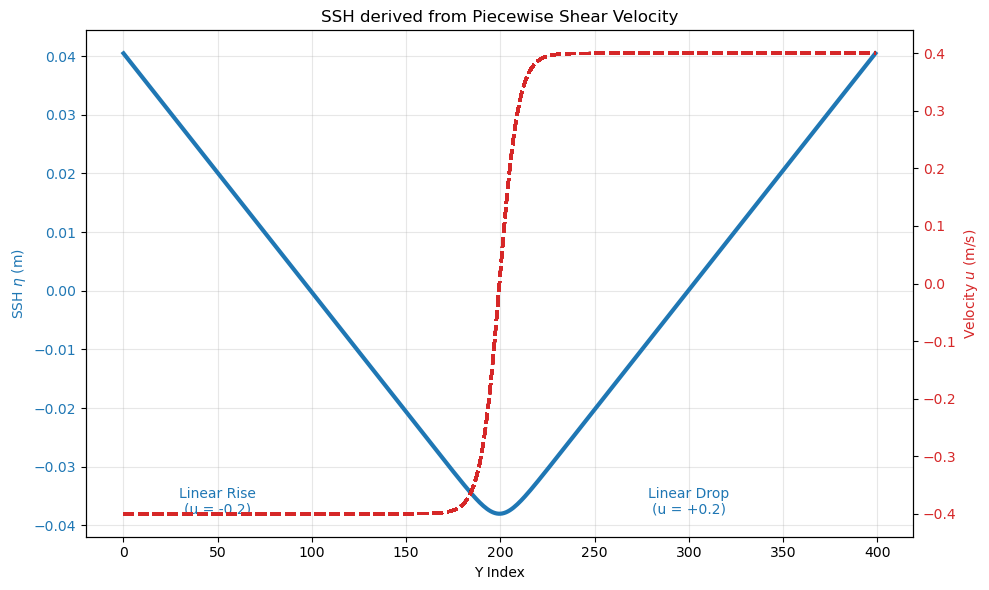

In [140]:
eta_1d = eta_t[:,10]
# ---------------------------------------------------------
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot SSH (Blue)
color = 'tab:blue'
ax1.set_xlabel('Y Index')
ax1.set_ylabel('SSH $\eta$ (m)', color=color)
ax1.plot(eta_1d, color=color, linewidth=3, label='SSH ($\eta$)')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, alpha=0.3)

# Highlight the shape
ax1.text(50, np.min(eta_1d), "Linear Rise\n(u = -0.2)", color=color, ha='center')
ax1.text(300, np.min(eta_1d), "Linear Drop\n(u = +0.2)", color=color, ha='center')

# Plot Velocity (Red)
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Velocity $u$ (m/s)', color=color)
ax2.plot(u, color=color, linestyle='--', linewidth=2, label='Velocity ($u$)')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('SSH derived from Piecewise Shear Velocity')
fig.tight_layout()
plt.show()

In [141]:
# 6. WRITE VELOCITY FILE (velocity_uv.nc)
nc_vel = Dataset("/scratch/nm03/ae7501/mom6_input_directories/idealized/test40/INPUT/init_vel.nc", "w", format="NETCDF4")
# 7. WRITE THICKNESS FILE (thickness_h.nc)
nc_h = Dataset("/scratch/nm03/ae7501/mom6_input_directories/idealized/test40/INPUT/init_eta.nc", "w", format="NETCDF4")

In [142]:
# 5. ADD Z COORDINATE
zl = 1
layer_thickness = 500.0  # meters , not clear if i need the z dimention for the one layer model
z = np.array([-250.0])   # Single layer index
# Expand fields to (zl, y, x) with proper dimensions
h_3d = eta_t[np.newaxis, :, :]            # (1, ny, nx)
u_3d = u[np.newaxis, :, :]            # (1, ny, nxp)
v_3d = v[np.newaxis, :, :]            # (1, nyp, nx)



# Create dimensions
nc_vel.createDimension("zl", zl)
nc_vel.createDimension("yh", ny)
nc_vel.createDimension("xh", nx)
nc_vel.createDimension("yq", nyp)
nc_vel.createDimension("xq", nxp)

# Create coordinate variables (1D arrays)
zl_var = nc_vel.createVariable("zl", "f4", ("zl",))
zl_var[:] = z
zl_var.axis = "Z"
zl_var.long_name = "depth to layer"

xh_var = nc_vel.createVariable("xh", "f4", ("xh",))
xh_var[:] = xh
xh_var.axis = "X"
xh_var.long_name = "h-point longitude"
xh_var.units = "meters"

yh_var = nc_vel.createVariable("yh", "f4", ("yh",))
yh_var[:] = yh
yh_var.axis = "Y"
yh_var.long_name = "h-point latitude"
yh_var.units = "meters"

xq_var = nc_vel.createVariable("xq", "f4", ("xq",))
xq_var[:] = xq
xq_var.axis = "X"
xq_var.long_name = "q-point longitude"
xq_var.units = "meters"

yq_var = nc_vel.createVariable("yq", "f4", ("yq",))
yq_var[:] = yq
yq_var.axis = "Y"
yq_var.long_name = "q-point latitude"
yq_var.units = "meters"

# Create velocity variables
u_var = nc_vel.createVariable("u", "f4", ("zl", "yh", "xq"))
u_var[:] = u_3d
u_var.units = "m s-1"
u_var.long_name = "Eastward velocity"
u_var.standard_name = "eastward_sea_water_velocity"

v_var = nc_vel.createVariable("v", "f4", ("zl", "yq", "xh"))
v_var[:] = v_3d
v_var.units = "m s-1"
v_var.long_name = "Northward velocity"
v_var.standard_name = "northward_sea_water_velocity"

nc_vel.regrid_method = "bilinear"
nc_vel.close()

print(f"Created velocity_uv.nc")
print(f"  u: ({zl}, {ny}, {nxp}) at (zl, yh, xq)")
print(f"  v: ({zl}, {nyp}, {nx}) at (zl, yq, xh)")



# Create dimensions
nc_h.createDimension("yh", ny)
nc_h.createDimension("xh", nx)

# Create coordinate variables (1D arrays)
xh_var2 = nc_h.createVariable("xh", "f4", ("xh",))
xh_var2[:] = xh
xh_var2.axis = "X"
xh_var2.long_name = "h-point longitude"
xh_var2.units = "meters"

yh_var2 = nc_h.createVariable("yh", "f4", ("yh",))
yh_var2[:] = yh
yh_var2.axis = "Y"
yh_var2.long_name = "h-point latitude"
yh_var2.units = "meters"

# Create thickness variable
h_var = nc_h.createVariable("eta_t", "f4", ("yh", "xh"))
h_var[:] = h_3d
h_var.units = "m"
h_var.long_name = "Layer thickness"
h_var.standard_name = "sea_floor_depth_below_sea_surface"

nc_h.close()

print(f"Created thickness_h.nc")
print(f"  h: ({ny}, {nx}) at (yh, xh)")

print("Staggered grid setup complete!")
print(f"  Grid: {nx} × {ny} cells")
print(f"  h: at cell centers (xh, yh)")
print(f"  u: at eastern faces (xq, yh)")
print(f"  v: at northern faces (xh, yq)")

Created velocity_uv.nc
  u: (1, 400, 1001) at (zl, yh, xq)
  v: (1, 401, 1000) at (zl, yq, xh)
Created thickness_h.nc
  h: (400, 1000) at (yh, xh)
Staggered grid setup complete!
  Grid: 1000 × 400 cells
  h: at cell centers (xh, yh)
  u: at eastern faces (xq, yh)
  v: at northern faces (xh, yq)


### case of a bent tanh profile

In [15]:
U = 0.20        # m/s
Ljet = 15e3     # jet half-width (m)

# Jet / slope curvature
bend_amp = 30e3       # meters (≈ 30 grid points)
Lx = nx * dx

# Centerline evaluated on different x-grids
y0 = Ly / 2

y_center_h = y0 + bend_amp * np.sin(2 * np.pi * xh / Lx)   # for eta/h
y_center_u = y0 + bend_amp * np.sin(2 * np.pi * xq / Lx)   # for u
y_center_v = y0 + bend_amp * np.sin(2 * np.pi * xh / Lx)   # for v


In [16]:
# Cross-stream coordinates
yprime_u = (Yh_u - y_center_u[np.newaxis, :]) / Ljet
yprime_v = (Yq   - y_center_v[np.newaxis, :]) / Ljet
yprime_h = (Yh   - y_center_h[np.newaxis, :]) / Ljet

In [17]:
u = -U * np.tanh(yprime_u)

In [18]:
dyc_dx = (2 * np.pi * bend_amp / Lx) * np.cos(2 * np.pi * xh / Lx)
#v = -U * dyc_dx[np.newaxis, :] * (1 / np.cosh(yprime_v)**2)


#sech2 = 1 / np.cosh(yprime_v)**2
#v = dyc_dx[np.newaxis, :] * U * np.tanh(yprime_v) * sech2
v = U * np.tanh(yprime_v) * dyc_dx[np.newaxis, :]


In [19]:
np.random.seed(1)

noise = np.random.randn(*u.shape)
decay = 1 / np.cosh(yprime_u)**2
u_noise = 1e-3 * decay * noise
u_final= u+ u_noise

In [20]:

# For a tanh jet, the integral gives the log-cosh form. still valid since the cross profile is still tanh and only centerline changes
eta = -(f * U * Ljet / g) * np.log(np.cosh(yprime_h))
eta_t = eta - eta.mean()

# v-component affects the along-stream pressure gradient but for a slowly varying jet (where bend_amp / Lx is small), the cross-stream balance dominates and the log-cosh approximation remains valid.

In [21]:
# 6. WRITE VELOCITY FILE (velocity_uv.nc)
nc_vel = Dataset("/scratch/nm03/ae7501/mom6_input_directories/idealized/test24/INPUT/init_vel2.nc", "w", format="NETCDF4")
# 7. WRITE THICKNESS FILE (thickness_h.nc)
nc_h = Dataset("/scratch/nm03/ae7501/mom6_input_directories/idealized/test24/INPUT/init_eta2.nc", "w", format="NETCDF4")

In [22]:
# 5. ADD Z COORDINATE
zl = 1
layer_thickness = 500.0  # meters , not clear if i need the z dimention for the one layer model
z = np.array([-250.0])   # Single layer index
# Expand fields to (zl, y, x) with proper dimensions
h_3d = eta_t[np.newaxis, :, :]            # (1, ny, nx)
u_3d = u[np.newaxis, :, :]            # (1, ny, nxp)
v_3d = v[np.newaxis, :, :]            # (1, nyp, nx)



# Create dimensions
nc_vel.createDimension("zl", zl)
nc_vel.createDimension("yh", ny)
nc_vel.createDimension("xh", nx)
nc_vel.createDimension("yq", nyp)
nc_vel.createDimension("xq", nxp)

# Create coordinate variables (1D arrays)
zl_var = nc_vel.createVariable("zl", "f4", ("zl",))
zl_var[:] = z
zl_var.axis = "Z"
zl_var.long_name = "depth to layer"

xh_var = nc_vel.createVariable("xh", "f4", ("xh",))
xh_var[:] = xh
xh_var.axis = "X"
xh_var.long_name = "h-point longitude"
xh_var.units = "meters"

yh_var = nc_vel.createVariable("yh", "f4", ("yh",))
yh_var[:] = yh
yh_var.axis = "Y"
yh_var.long_name = "h-point latitude"
yh_var.units = "meters"

xq_var = nc_vel.createVariable("xq", "f4", ("xq",))
xq_var[:] = xq
xq_var.axis = "X"
xq_var.long_name = "q-point longitude"
xq_var.units = "meters"

yq_var = nc_vel.createVariable("yq", "f4", ("yq",))
yq_var[:] = yq
yq_var.axis = "Y"
yq_var.long_name = "q-point latitude"
yq_var.units = "meters"

# Create velocity variables
u_var = nc_vel.createVariable("u", "f4", ("zl", "yh", "xq"))
u_var[:] = u_3d
u_var.units = "m s-1"
u_var.long_name = "Eastward velocity"
u_var.standard_name = "eastward_sea_water_velocity"

v_var = nc_vel.createVariable("v", "f4", ("zl", "yq", "xh"))
v_var[:] = v_3d
v_var.units = "m s-1"
v_var.long_name = "Northward velocity"
v_var.standard_name = "northward_sea_water_velocity"

nc_vel.regrid_method = "bilinear"
nc_vel.close()

print(f"Created velocity_uv.nc")
print(f"  u: ({zl}, {ny}, {nxp}) at (zl, yh, xq)")
print(f"  v: ({zl}, {nyp}, {nx}) at (zl, yq, xh)")



# Create dimensions
nc_h.createDimension("yh", ny)
nc_h.createDimension("xh", nx)

# Create coordinate variables (1D arrays)
xh_var2 = nc_h.createVariable("xh", "f4", ("xh",))
xh_var2[:] = xh
xh_var2.axis = "X"
xh_var2.long_name = "h-point longitude"
xh_var2.units = "meters"

yh_var2 = nc_h.createVariable("yh", "f4", ("yh",))
yh_var2[:] = yh
yh_var2.axis = "Y"
yh_var2.long_name = "h-point latitude"
yh_var2.units = "meters"

# Create thickness variable
h_var = nc_h.createVariable("eta_t", "f4", ("yh", "xh"))
h_var[:] = h_3d
h_var.units = "m"
h_var.long_name = "Layer thickness"
h_var.standard_name = "sea_floor_depth_below_sea_surface"

nc_h.close()

print(f"Created thickness_h.nc")
print(f"  h: ({ny}, {nx}) at (yh, xh)")

print("Staggered grid setup complete!")
print(f"  Grid: {nx} × {ny} cells")
print(f"  h: at cell centers (xh, yh)")
print(f"  u: at eastern faces (xq, yh)")
print(f"  v: at northern faces (xh, yq)")

Created velocity_uv.nc
  u: (1, 400, 1001) at (zl, yh, xq)
  v: (1, 401, 1000) at (zl, yq, xh)
Created thickness_h.nc
  h: (400, 1000) at (yh, xh)
Staggered grid setup complete!
  Grid: 1000 × 400 cells
  h: at cell centers (xh, yh)
  u: at eastern faces (xq, yh)
  v: at northern faces (xh, yq)


#### eta by integration

In [1]:
deta_dy = f0 * u[:, :-1] / g


NameError: name 'f0' is not defined

In [2]:
eta = np.zeros((ny, nx))

eta[1:, :] = np.cumsum(deta_dy[1:, :], axis=0) * dy

NameError: name 'np' is not defined

In [ ]:
eta -= eta.mean()

#### plots for the bent tanh profile

/jobfs/159365779.gadi-pbs/ipykernel_1459071/1643481509.py:12: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


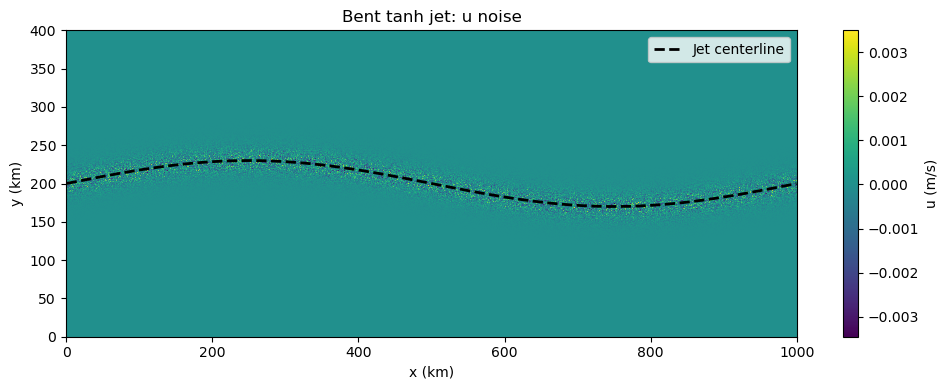

/jobfs/159365779.gadi-pbs/ipykernel_1459071/1643481509.py:26: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


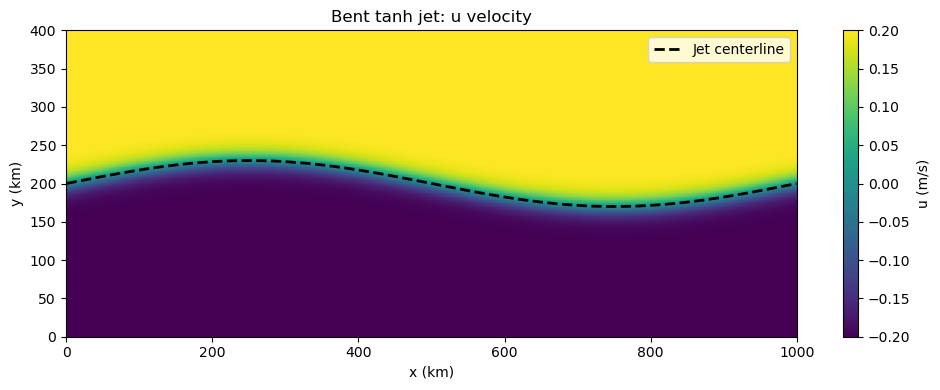

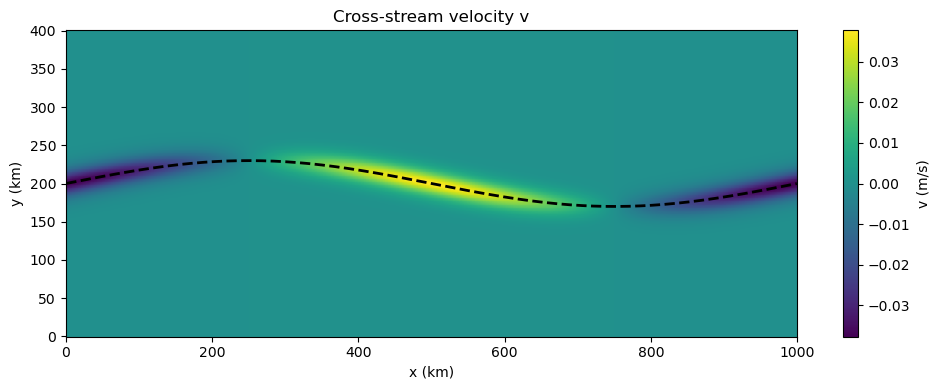

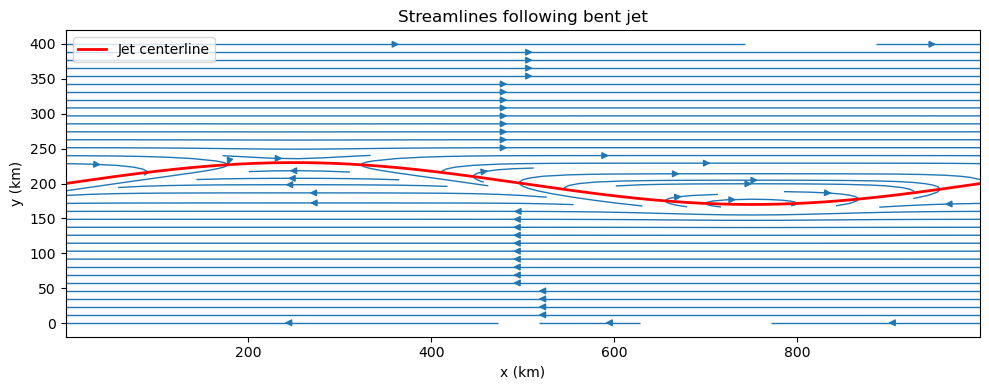

In [19]:
# =========================
# 1. u noise (eastward)
# =========================
plt.figure(figsize=(10, 4))
plt.pcolormesh(xq / 1e3, yh / 1e3, u_noise, shading="auto")
plt.colorbar(label="u (m/s)")
plt.plot(xh / 1e3, y_center_h / 1e3,"k--", linewidth=2, label="Jet centerline")
plt.xlabel("x (km)")
plt.ylabel("y (km)")
plt.title("Bent tanh jet: u noise")
plt.legend()
plt.tight_layout()
plt.show()

# =========================
# 1. u velocity (eastward)
# =========================
plt.figure(figsize=(10, 4))
plt.pcolormesh(xq / 1e3, yh / 1e3, u_final, shading="auto")
plt.colorbar(label="u (m/s)")
plt.plot(xh / 1e3, y_center_h / 1e3,"k--", linewidth=2, label="Jet centerline")
plt.xlabel("x (km)")
plt.ylabel("y (km)")
plt.title("Bent tanh jet: u velocity")
plt.legend()
plt.tight_layout()
plt.show()


# =========================
# 2. v velocity (cross-stream)
# =========================
plt.figure(figsize=(10, 4))
plt.pcolormesh(
    xh / 1e3, yq / 1e3, v,
    shading="auto"
)
plt.colorbar(label="v (m/s)")
plt.plot(
    xh / 1e3, y_center_h / 1e3,
    "k--", linewidth=2
)
plt.xlabel("x (km)")
plt.ylabel("y (km)")
plt.title("Cross-stream velocity v")
plt.tight_layout()
plt.show()


# =========================
# 3. Streamlines
# =========================
plt.figure(figsize=(10, 4))

# streamplot requires u and v on the same grid
# use interior points to align shapes
plt.streamplot(
    xh / 1e3, yh / 1e3,
    u[:, :-1], v[:-1, :],
    density=1.2, linewidth=1
)

plt.plot(
    xh / 1e3, y_center_h / 1e3,
    "r", linewidth=2, label="Jet centerline"
)

plt.xlabel("x (km)")
plt.ylabel("y (km)")
plt.title("Streamlines following bent jet")
plt.legend()
plt.tight_layout()
plt.show()



Sea Surface Height Statistics:
  Min: -0.0447 m
  Max: -0.0000 m
  Mean: -0.018591 m
  Std: 0.0120 m
  Range: 0.0447 m


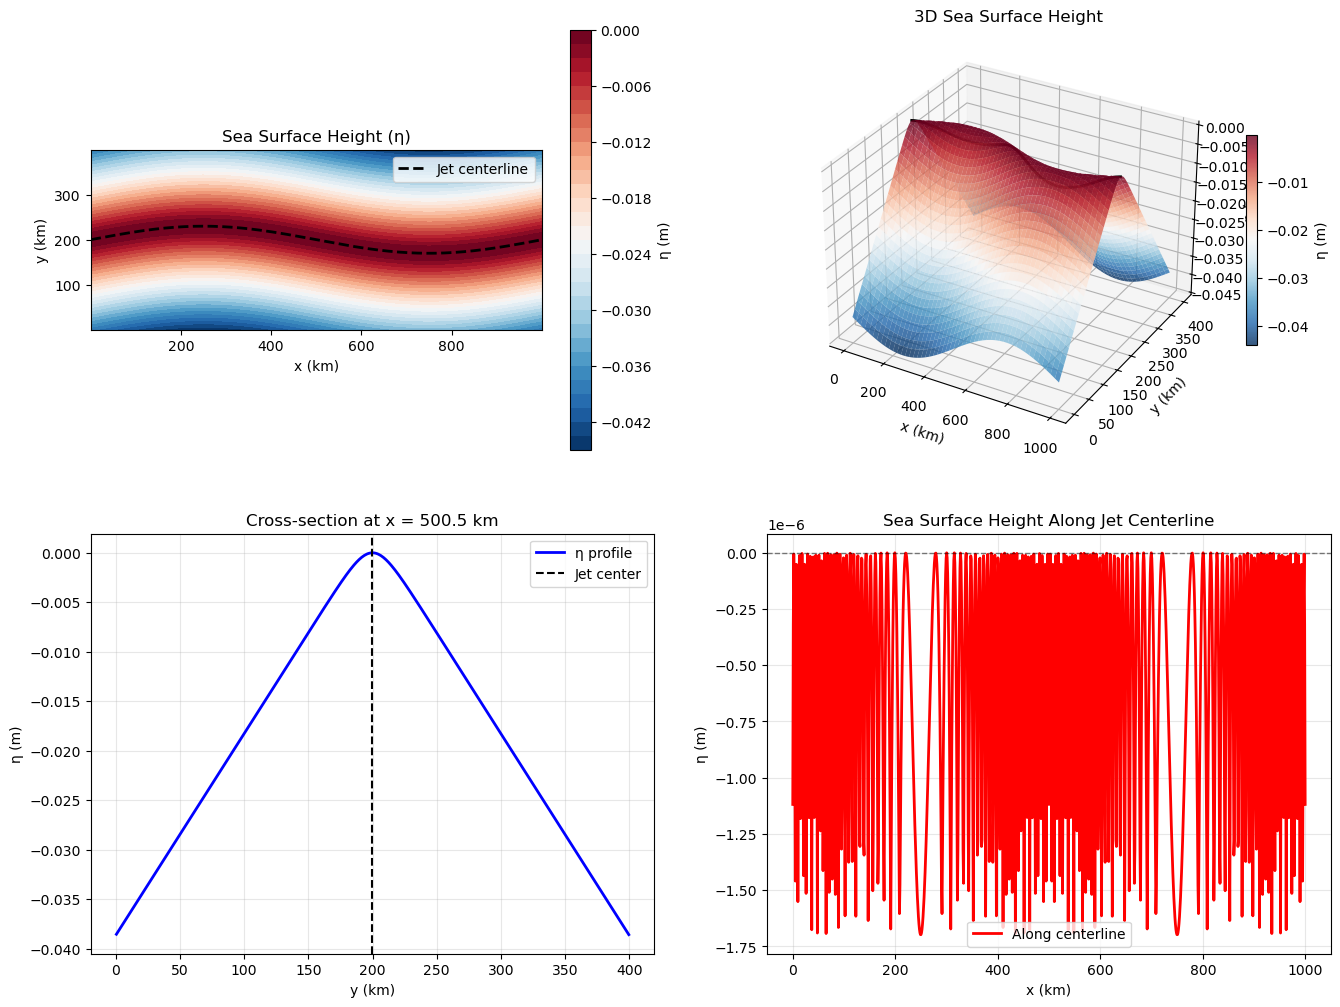

In [20]:
# Create visualization
fig = plt.figure(figsize=(16, 12))

# 1. Sea surface height with jet centerline
ax1 = plt.subplot(2, 2, 1)
im1 = ax1.contourf(Xh/1e3, Yh/1e3, eta, levels=30, cmap='RdBu_r')
ax1.plot(xh/1e3, y_center_h/1e3, 'k--', linewidth=2, label='Jet centerline')
plt.colorbar(im1, ax=ax1, label='η (m)')
ax1.set_xlabel('x (km)')
ax1.set_ylabel('y (km)')
ax1.set_title('Sea Surface Height (η)')
ax1.legend()
ax1.set_aspect('equal')

# 2. 3D surface plot of eta
ax2 = plt.subplot(2, 2, 2, projection='3d')
surf = ax2.plot_surface(Xh/1e3, Yh/1e3, eta, cmap='RdBu_r', 
                        edgecolor='none', alpha=0.8)
ax2.plot(xh/1e3, y_center_h/1e3, eta[ny//2, :], 'k-', linewidth=2)
ax2.set_xlabel('x (km)')
ax2.set_ylabel('y (km)')
ax2.set_zlabel('η (m)')
ax2.set_title('3D Sea Surface Height')
plt.colorbar(surf, ax=ax2, label='η (m)', shrink=0.5)

# 3. Cross-section through the middle
ax3 = plt.subplot(2, 2, 3)
mid_idx = nx // 2
ax3.plot(yh/1e3, eta[:, mid_idx], 'b-', linewidth=2, label='η profile')
ax3.axvline(y_center_h[mid_idx]/1e3, color='k', linestyle='--', 
            linewidth=1.5, label='Jet center')
ax3.set_xlabel('y (km)')
ax3.set_ylabel('η (m)')
ax3.set_title(f'Cross-section at x = {xh[mid_idx]/1e3:.1f} km')
ax3.grid(True, alpha=0.3)
ax3.legend()

# 4. Along-stream variation
ax4 = plt.subplot(2, 2, 4)
# Extract eta along the jet centerline
eta_centerline = np.array([eta[np.argmin(np.abs(yh - y_center_h[i])), i] 
                           for i in range(nx)])
ax4.plot(xh/1e3, eta_centerline, 'r-', linewidth=2, label='Along centerline')
ax4.axhline(0, color='k', linestyle='--', linewidth=1, alpha=0.5)
ax4.set_xlabel('x (km)')
ax4.set_ylabel('η (m)')
ax4.set_title('Sea Surface Height Along Jet Centerline')
ax4.grid(True, alpha=0.3)
ax4.legend()



# Print statistics
print(f"\nSea Surface Height Statistics:")
print(f"  Min: {eta.min():.4f} m")
print(f"  Max: {eta.max():.4f} m")
print(f"  Mean: {eta.mean():.6f} m")
print(f"  Std: {eta.std():.4f} m")
print(f"  Range: {eta.max() - eta.min():.4f} m")

### case of a half tanh profile/ one directional current

In [4]:
U = 0.40      # m/s
Ljet = 10e3  # m
y0 = Ly/2    # m

yprime_h = (Yh - y0) / Ljet      # for eta
yprime_u = (Yh_u - y0) / Ljet    # for u
yprime_v = (Yq - y0) / Ljet      # for v

# 3. VELOCITY FIELDS (Bickley Jet) ON STAGGERED GRID
# u at (ny, nx+1) - eastern faces
u = U * np.tanh(yprime_u)
u = np.where(u < 0, 0, u)

u_clean = u
# v at (ny+1, nx) - northern faces
v = np.zeros((ny+1, nx))

# Add small decaying noise to u
random_noise = np.random.randn(*u.shape)
decay_factor = 1 / np.cosh(yprime_u)**2   # sech^2
noise = 1e-3 * decay_factor * random_noise
u = u + noise
# 4. FREE SURFACE / THICKNESS FIELD
#f=2* 7.292e-5*math.sin(math.radians(-15))

In [5]:
u_noise = u-u_clean

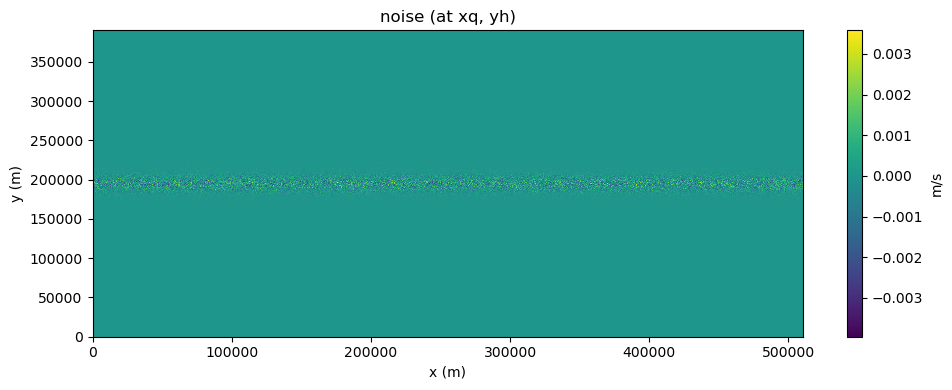

In [6]:
# PLOTTING
# Plot u
plt.figure(figsize=(10,4))
plt.title("noise (at xq, yh)")
plt.pcolormesh(Xq, Yh_u, u_noise, shading='auto')
plt.colorbar(label="m/s")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.tight_layout()
plt.show()

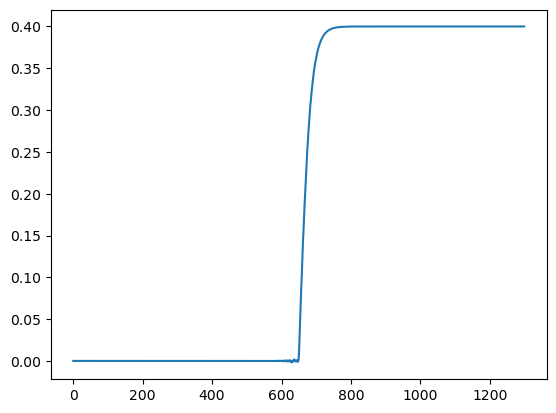

In [7]:
plt.plot(u[:,10])

In [8]:
# u on h-grid (interpolate from xq to xh)
u_on_h = 0.5 * (u_clean[:, :-1] + u_clean[:, 1:])   # (ny, nx)

# Integrate geostrophic balance: dη/dy = -f*u/g
# η(y) = η(y0) + integral from y0 to y of (-f*u/g) dy
dy_val = yh[1] - yh[0]
deta_dy = -f * u_on_h / g                            # (ny, nx)
eta_t = np.cumsum(deta_dy, axis=0) * dy_val          # integrate in y
eta_t -= eta_t.mean()                                # remove mean


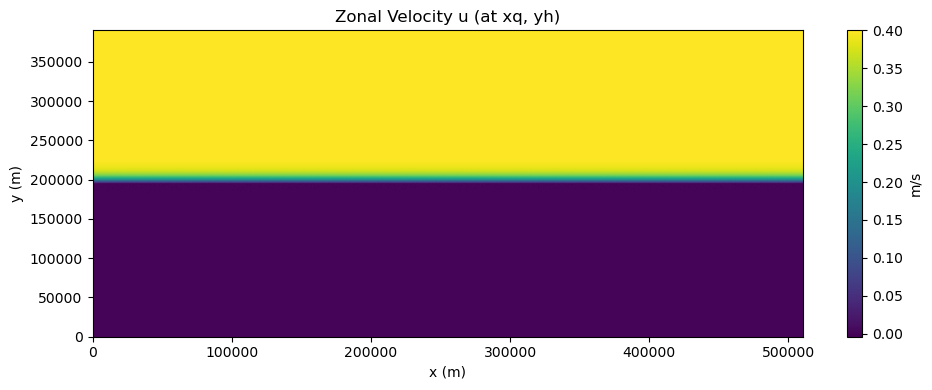

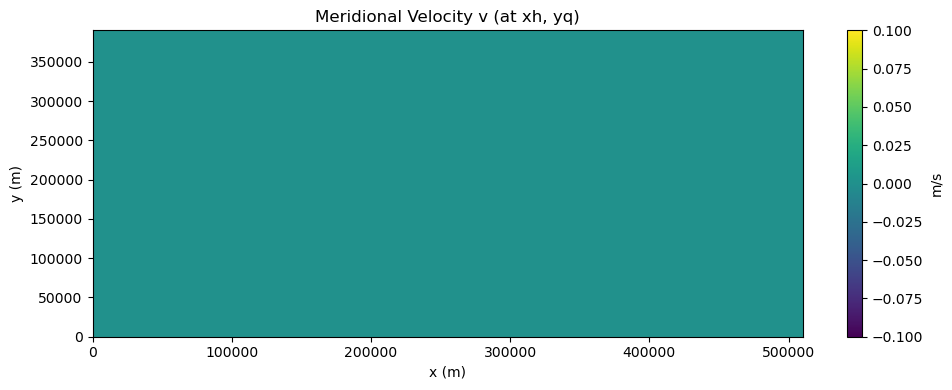

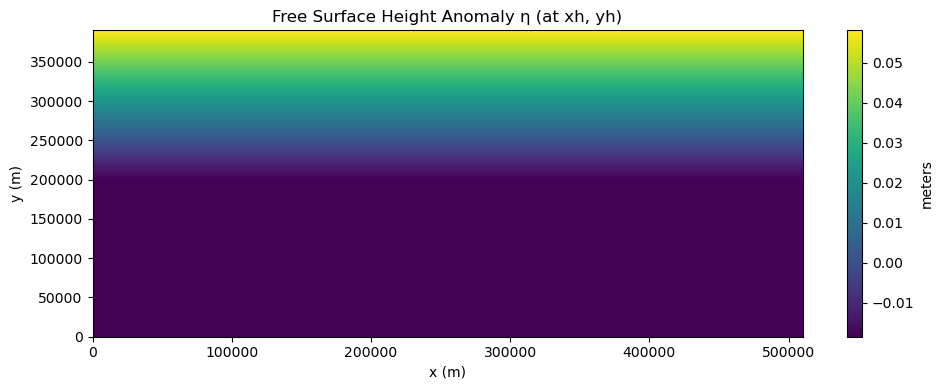

In [9]:

# PLOTTING
# Plot u
plt.figure(figsize=(10,4))
plt.title("Zonal Velocity u (at xq, yh)")
plt.pcolormesh(Xq, Yh_u, u, shading='auto')
plt.colorbar(label="m/s")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.tight_layout()
plt.show()

# Plot v
plt.figure(figsize=(10,4))
plt.title("Meridional Velocity v (at xh, yq)")
plt.pcolormesh(Xh_v, Yq, v, shading='auto')
plt.colorbar(label="m/s")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.tight_layout()
plt.show()

# Plot eta
plt.figure(figsize=(10,4))
plt.title("Free Surface Height Anomaly η (at xh, yh)")
plt.pcolormesh(xh, yh, eta_t, shading='auto')
plt.colorbar(label="meters")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.tight_layout()
plt.show()

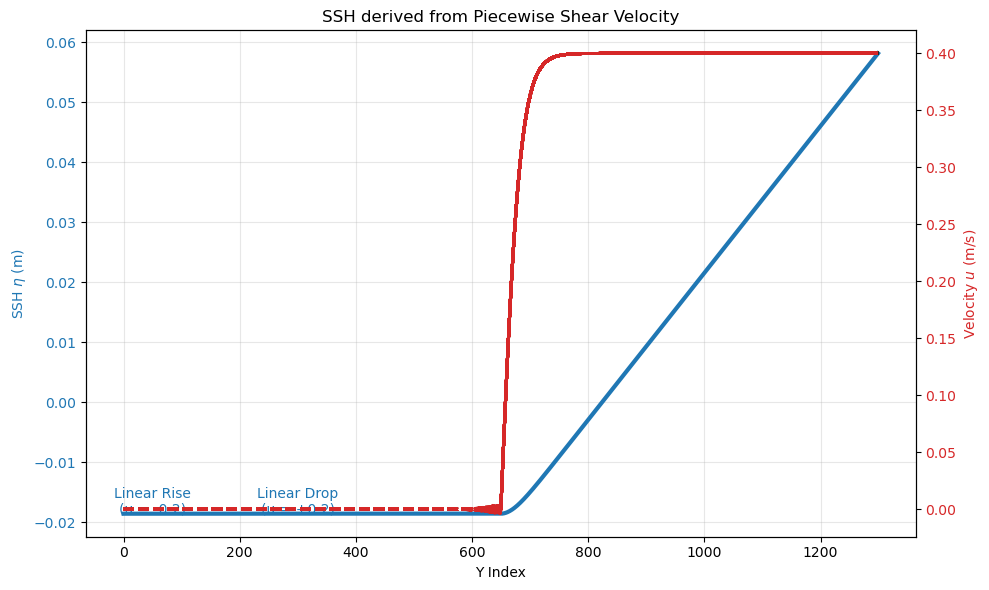

In [10]:
eta_1d = eta_t[:,10]
# ---------------------------------------------------------
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot SSH (Blue)
color = 'tab:blue'
ax1.set_xlabel('Y Index')
ax1.set_ylabel('SSH $\eta$ (m)', color=color)
ax1.plot(eta_1d, color=color, linewidth=3, label='SSH ($\eta$)')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, alpha=0.3)

# Highlight the shape
ax1.text(50, np.min(eta_1d), "Linear Rise\n(u = -0.2)", color=color, ha='center')
ax1.text(300, np.min(eta_1d), "Linear Drop\n(u = +0.2)", color=color, ha='center')

# Plot Velocity (Red)
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Velocity $u$ (m/s)', color=color)
ax2.plot(u, color=color, linestyle='--', linewidth=2, label='Velocity ($u$)')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('SSH derived from Piecewise Shear Velocity')
fig.tight_layout()
plt.show()

In [18]:
# 6. WRITE VELOCITY FILE (velocity_uv.nc)
nc_vel = Dataset("/scratch/nm03/ae7501/mom6_input_directories/idealized/test0001/INPUT/init_vel.nc", "w", format="NETCDF4")
# 7. WRITE THICKNESS FILE (thickness_h.nc)
nc_h = Dataset("/scratch/nm03/ae7501/mom6_input_directories/idealized/test0001/INPUT/init_eta.nc", "w", format="NETCDF4")

In [19]:
# 5. ADD Z COORDINATE
zl = 1
layer_thickness = 500.0  # meters , not clear if i need the z dimention for the one layer model
z = np.array([-250.0])   # Single layer index
# Expand fields to (zl, y, x) with proper dimensions
h_3d = eta_t[np.newaxis, :, :]            # (1, ny, nx)
u_3d = u[np.newaxis, :, :]            # (1, ny, nxp)
v_3d = v[np.newaxis, :, :]            # (1, nyp, nx)



# Create dimensions
nc_vel.createDimension("zl", zl)
nc_vel.createDimension("yh", ny)
nc_vel.createDimension("xh", nx)
nc_vel.createDimension("yq", nyp)
nc_vel.createDimension("xq", nxp)

# Create coordinate variables (1D arrays)
zl_var = nc_vel.createVariable("zl", "f4", ("zl",))
zl_var[:] = z
zl_var.axis = "Z"
zl_var.long_name = "depth to layer"

xh_var = nc_vel.createVariable("xh", "f4", ("xh",))
xh_var[:] = xh
xh_var.axis = "X"
xh_var.long_name = "h-point longitude"
xh_var.units = "meters"

yh_var = nc_vel.createVariable("yh", "f4", ("yh",))
yh_var[:] = yh
yh_var.axis = "Y"
yh_var.long_name = "h-point latitude"
yh_var.units = "meters"

xq_var = nc_vel.createVariable("xq", "f4", ("xq",))
xq_var[:] = xq
xq_var.axis = "X"
xq_var.long_name = "q-point longitude"
xq_var.units = "meters"

yq_var = nc_vel.createVariable("yq", "f4", ("yq",))
yq_var[:] = yq
yq_var.axis = "Y"
yq_var.long_name = "q-point latitude"
yq_var.units = "meters"

# Create velocity variables
u_var = nc_vel.createVariable("u", "f4", ("zl", "yh", "xq"))
u_var[:] = u_3d
u_var.units = "m s-1"
u_var.long_name = "Eastward velocity"
u_var.standard_name = "eastward_sea_water_velocity"

v_var = nc_vel.createVariable("v", "f4", ("zl", "yq", "xh"))
v_var[:] = v_3d
v_var.units = "m s-1"
v_var.long_name = "Northward velocity"
v_var.standard_name = "northward_sea_water_velocity"

nc_vel.regrid_method = "bilinear"
nc_vel.close()

print(f"Created velocity_uv.nc")
print(f"  u: ({zl}, {ny}, {nxp}) at (zl, yh, xq)")
print(f"  v: ({zl}, {nyp}, {nx}) at (zl, yq, xh)")



# Create dimensions
nc_h.createDimension("yh", ny)
nc_h.createDimension("xh", nx)

# Create coordinate variables (1D arrays)
xh_var2 = nc_h.createVariable("xh", "f4", ("xh",))
xh_var2[:] = xh
xh_var2.axis = "X"
xh_var2.long_name = "h-point longitude"
xh_var2.units = "meters"

yh_var2 = nc_h.createVariable("yh", "f4", ("yh",))
yh_var2[:] = yh
yh_var2.axis = "Y"
yh_var2.long_name = "h-point latitude"
yh_var2.units = "meters"

# Create thickness variable
h_var = nc_h.createVariable("eta_t", "f4", ("yh", "xh"))
h_var[:] = h_3d
h_var.units = "m"
h_var.long_name = "Layer thickness"
h_var.standard_name = "sea_floor_depth_below_sea_surface"

nc_h.close()

print(f"Created thickness_h.nc")
print(f"  h: ({ny}, {nx}) at (yh, xh)")

print("Staggered grid setup complete!")
print(f"  Grid: {nx} × {ny} cells")
print(f"  h: at cell centers (xh, yh)")
print(f"  u: at eastern faces (xq, yh)")
print(f"  v: at northern faces (xh, yq)")

Created velocity_uv.nc
  u: (1, 1300, 1701) at (zl, yh, xq)
  v: (1, 1301, 1700) at (zl, yq, xh)
Created thickness_h.nc
  h: (1300, 1700) at (yh, xh)
Staggered grid setup complete!
  Grid: 1700 × 1300 cells
  h: at cell centers (xh, yh)
  u: at eastern faces (xq, yh)
  v: at northern faces (xh, yq)


## Bathymetry 

In [13]:
import numpy as np
from netCDF4 import Dataset

In [14]:
'''
#  DEFINE CARTESIAN MOM6 STAGGERED GRID
Lx = 1000e3   # 1000 km
Ly = 400e3    # 400 km
dx = 1000     # 1 km
dy = 1000

nx = int(Lx/dx)     # number of h-points in x
ny = int(Ly/dy)     # number of h-points in y
nxp = nx + 1        # u-points in x
nyp = ny + 1        # v-points in y

# h-points (cell centers)
xh = np.linspace(dx/2, Lx - dx/2, nx)    # size nx
yh = np.linspace(dy/2, Ly - dy/2, ny)    # size ny
'''

'\n#  DEFINE CARTESIAN MOM6 STAGGERED GRID\nLx = 1000e3   # 1000 km\nLy = 400e3    # 400 km\ndx = 1000     # 1 km\ndy = 1000\n\nnx = int(Lx/dx)     # number of h-points in x\nny = int(Ly/dy)     # number of h-points in y\nnxp = nx + 1        # u-points in x\nnyp = ny + 1        # v-points in y\n\n# h-points (cell centers)\nxh = np.linspace(dx/2, Lx - dx/2, nx)    # size nx\nyh = np.linspace(dy/2, Ly - dy/2, ny)    # size ny\n'

In [15]:
shallow_depth  = 100.0   # m
deep_depth     = 500.0   # m
slope_width_m  = 4800.0  # m  (5 km physical — gives 16 cells = 4.8 km at 300m res)
Ys             = Ly / 2  # m  slope centre at 195 km

# Slope indices — centred at Ys using left-edge method
slope_width_cells = int(slope_width_m / dy)           # 16 cells
half_width        = slope_width_m / 2.0
slope_start       = int(round((Ys - half_width) / dy))  # 642
slope_end         = slope_start + slope_width_cells      # 658

# Build 1-D depth profile
depth_profile_y = np.zeros(ny)
depth_profile_y[:slope_start]            = shallow_depth                              # flat shelf 100m
depth_profile_y[slope_start:slope_end]   = np.linspace(shallow_depth, deep_depth,    # linear slope
                                                         slope_width_cells)
depth_profile_y[slope_end:]              = deep_depth                                 # flat basin 500m

# Tile into 2-D array (ny, nx)
depth_2d = np.tile(depth_profile_y[:, np.newaxis], (1, nx))
print(f"Shape: {depth_2d.shape}")

Shape: (1300, 1700)


In [171]:
'''
# Initialize depth array for y-axis
depth_profile_y = np.zeros(ny)

# 1. Depth drops from 100 to 100 between ny=0 and ny=190
depth_profile_y[0:175] = np.linspace(100, 100, 175) # (shallow_depth, deeper_Depth, no_of _indices_from_ny_start_to_end)

#Depth drops from 100 to 500 between ny=190 and ny=225--36 indices
# overlap at ny=190 to ensure continuity
depth_profile_y[175:225] = np.linspace(100, 500, 50)

# Depth is flat at 500 from ny=225 onwards
depth_profile_y[225:] = 500

# Create the 2D array by repeating the Y profile across the X dimension
# Shape will be (400, 1000)
depth_2d = np.tile(depth_profile_y[:, np.newaxis], (1, nx))

print(f"Shape: {depth_2d.shape}")
'''

Shape: (400, 1000)


In [20]:
# 7. WRITE THICKNESS FILE (thickness_h.nc)
nc_d = Dataset("/scratch/nm03/ae7501/mom6_input_directories/idealized/test0001/INPUT/ocean_topog.nc", "w", format="NETCDF4")
# Dimensions
nc_d.createDimension("yh", ny)
nc_d.createDimension("xh", nx)

xh_var = nc_d.createVariable("xh", "f4", ("xh",))
xh_var[:] = xh
xh_var.long_name = "t-cell center x-location"
xh_var.units = "meters"

yh_var = nc_d.createVariable("yh", "f4", ("yh",))
yh_var[:] = yh
yh_var.long_name = "t-cell center y-location"
yh_var.units = "meters"

# Topography variable
depth_var = nc_d.createVariable("depth", "f4", ("yh", "xh"))
depth_var[:] = depth_2d
depth_var.units = "m"
depth_var.long_name = "ocean bottom depth"
depth_var.standard_name = "sea_floor_depth_below_geoid"

nc_d.close()

print(" ocean_topog.nc written:")
print("shape =", depth_2d.shape, " = (ny, nx)")

 ocean_topog.nc written:
shape = (1300, 1700)  = (ny, nx)


### Add roughness

In [117]:
depth_profile_y_orig = depth_profile_y.copy()
y = np.arange(ny)


In [118]:
slope_start = 190
slope_end   = 225
slope_mask = (y >= slope_start) & (y <= slope_end)  # I am confining the roughness to this region as eddies interact within this region


In [138]:
x = np.arange(nx)

bulge_amp =30     # grid points 
bulge_wavelength = 2000

# Always-positive bulges
delta_y = -bulge_amp * (0.5 + 0.5 * np.sin(2 * np.pi * x / bulge_wavelength))




In [139]:
depth_2d_bulged = np.zeros((ny, nx))

for i in range(nx):
    y_shifted = y.copy()
    y_shifted[slope_mask] = y[slope_mask] - delta_y[i]

    # Prevent out-of-bounds
    y_shifted = np.clip(y_shifted, 0, ny - 1)

    # Interpolate original profile onto shifted coordinates
    depth_2d_bulged[:, i] = np.interp(
        y, y_shifted, depth_profile_y_orig
    )


In [140]:
depth_2d_bulged = np.clip(depth_2d_bulged, 0, 500)


In [141]:
# modifies the bulge to center of the slope
'''
mid = 0.5 * (slope_start + slope_end)
width = slope_end - slope_start

y_weight = np.exp(-((y - mid) / (0.3 * width))**2)

for i in range(nx):
    y_shifted = y.copy()
    y_shifted[slope_mask] = y[slope_mask] - delta_y[i] * y_weight[slope_mask]
    depth_2d_bulged[:, i] = np.interp(y, y_shifted, depth_profile_y_orig)
'''

'\nmid = 0.5 * (slope_start + slope_end)\nwidth = slope_end - slope_start\n\ny_weight = np.exp(-((y - mid) / (0.3 * width))**2)\n\nfor i in range(nx):\n    y_shifted = y.copy()\n    y_shifted[slope_mask] = y[slope_mask] - delta_y[i] * y_weight[slope_mask]\n    depth_2d_bulged[:, i] = np.interp(y, y_shifted, depth_profile_y_orig)\n'

In [142]:
# 7. WRITE THICKNESS FILE (thickness_h.nc)
nc_d = Dataset("/scratch/nm03/ae7501/mom6_input_directories/idealized/test22/INPUT/ocean_topog.nc", "w", format="NETCDF4")
# Dimensions
nc_d.createDimension("yh", ny)
nc_d.createDimension("xh", nx)

xh_var = nc_d.createVariable("xh", "f4", ("xh",))
xh_var[:] = xh
xh_var.long_name = "t-cell center x-location"
xh_var.units = "meters"

yh_var = nc_d.createVariable("yh", "f4", ("yh",))
yh_var[:] = yh
yh_var.long_name = "t-cell center y-location"
yh_var.units = "meters"

# Topography variable
depth_var = nc_d.createVariable("depth", "f4", ("yh", "xh"))
depth_var[:] = depth_2d_bulged
depth_var.units = "m"
depth_var.long_name = "ocean bottom depth"
depth_var.standard_name = "sea_floor_depth_below_geoid"

nc_d.close()

print(" ocean_topog.nc written:")
print("shape =", depth_2d.shape, " = (ny, nx)")

 ocean_topog.nc written:
shape = (400, 1000)  = (ny, nx)


### curved slope

In [24]:
depth_profile_y0 = depth_profile_y.copy()
y = np.arange(ny)
x = np.arange(nx)

In [25]:
Lx = nx                 # domain length (1000)
bend_amp = 30.0         # grid points in y (controls curvature strength)

# Sinusoidal lateral displacement of the slope
delta_y = bend_amp * np.sin(2 * np.pi * x / Lx)
delta_y = -delta_y

In [26]:
depth_2d_bent = np.zeros((ny, nx))

for i in range(nx):
    # Shift y-coordinates for this x
    y_shifted = y - delta_y[i]

    # Keep within bounds
    y_shifted = np.clip(y_shifted, 0, ny - 1)

    # Interpolate original profile onto shifted coordinates
    depth_2d_bent[:, i] = np.interp(
        y,                 # target y
        y_shifted,         # shifted coordinates
        depth_profile_y0   # original straight-slope profile
    )


In [27]:
# 7. WRITE THICKNESS FILE (thickness_h.nc)
nc_d = Dataset("/scratch/nm03/ae7501/mom6_input_directories/idealized/test23/INPUT/ocean_topog.nc", "w", format="NETCDF4")
# Dimensions
nc_d.createDimension("yh", ny)
nc_d.createDimension("xh", nx)

xh_var = nc_d.createVariable("xh", "f4", ("xh",))
xh_var[:] = xh
xh_var.long_name = "t-cell center x-location"
xh_var.units = "meters"

yh_var = nc_d.createVariable("yh", "f4", ("yh",))
yh_var[:] = yh
yh_var.long_name = "t-cell center y-location"
yh_var.units = "meters"

# Topography variable
depth_var = nc_d.createVariable("depth", "f4", ("yh", "xh"))
depth_var[:] = depth_2d_bent
depth_var.units = "m"
depth_var.long_name = "ocean bottom depth"
depth_var.standard_name = "sea_floor_depth_below_geoid"

nc_d.close()

print(" ocean_topog.nc written:")
print("shape =", depth_2d.shape, " = (ny, nx)")

 ocean_topog.nc written:
shape = (400, 1000)  = (ny, nx)


## check output

In [21]:
topo_file = xr.open_dataset('/scratch/nm03/ae7501/mom6_input_directories/idealized/test0001/INPUT/ocean_topog.nc')

In [22]:
topo_file

<xarray.Dataset> Size: 9MB
Dimensions:  (yh: 1300, xh: 1700)
Coordinates:
  * yh       (yh) float32 5kB 150.0 450.0 750.0 ... 3.896e+05 3.898e+05
  * xh       (xh) float32 7kB 150.0 450.0 750.0 ... 5.096e+05 5.098e+05
Data variables:
    depth    (yh, xh) float32 9MB ...

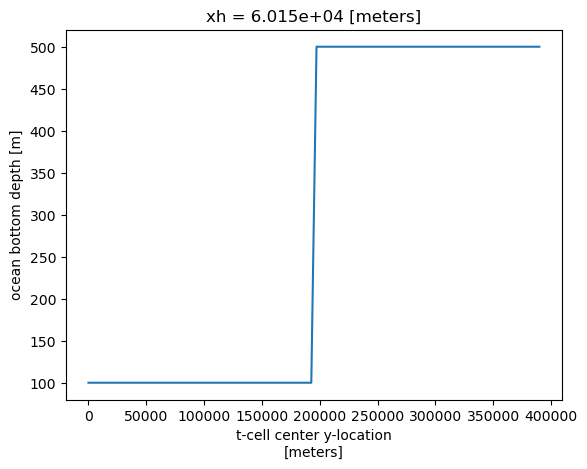

In [23]:
topo_file.depth.isel(xh=200).plot()

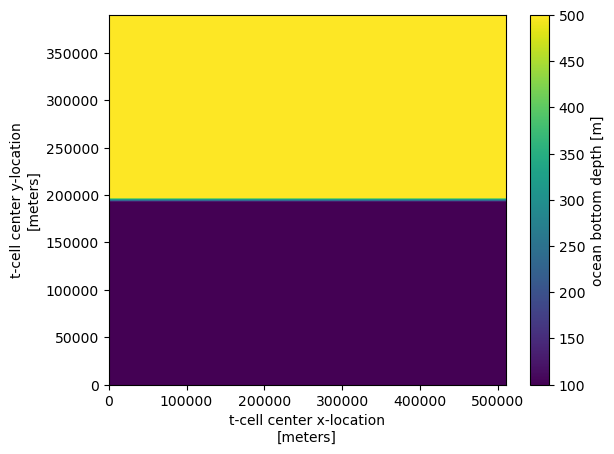

In [24]:
topo_file.depth.plot(robust=True)

In [25]:
vel_file = xr.open_dataset('/scratch/nm03/ae7501/mom6_input_directories/idealized/test0001/INPUT/init_vel.nc')

In [26]:
vel_file

<xarray.Dataset> Size: 18MB
Dimensions:  (zl: 1, yh: 1300, xq: 1701, yq: 1301, xh: 1700)
Coordinates:
  * zl       (zl) float32 4B -250.0
  * yh       (yh) float32 5kB 150.0 450.0 750.0 ... 3.896e+05 3.898e+05
  * xq       (xq) float32 7kB 0.0 300.0 600.0 ... 5.094e+05 5.097e+05 5.1e+05
  * yq       (yq) float32 5kB 0.0 300.0 600.0 ... 3.894e+05 3.897e+05 3.9e+05
  * xh       (xh) float32 7kB 150.0 450.0 750.0 ... 5.096e+05 5.098e+05
Data variables:
    u        (zl, yh, xq) float32 9MB ...
    v        (zl, yq, xh) float32 9MB ...
Attributes:
    regrid_method:  bilinear

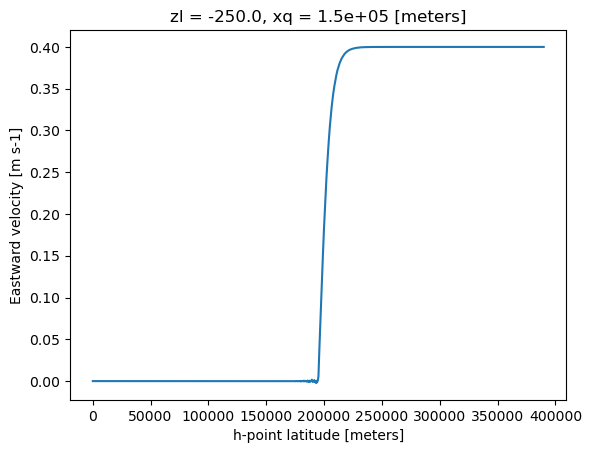

In [27]:
vel_file.u.isel(zl=0, xq=500).plot()

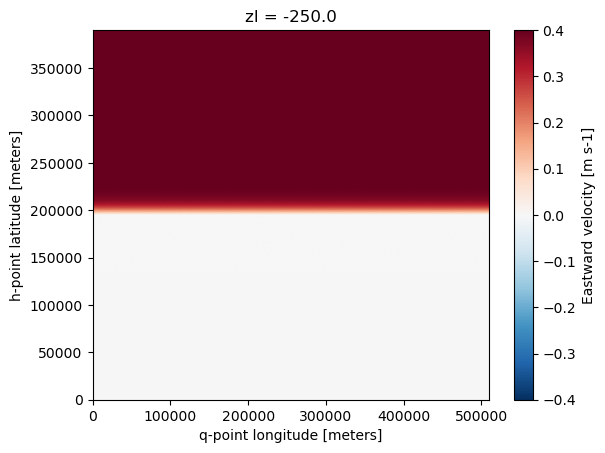

In [28]:
vel_file.u.isel(zl=0).plot()

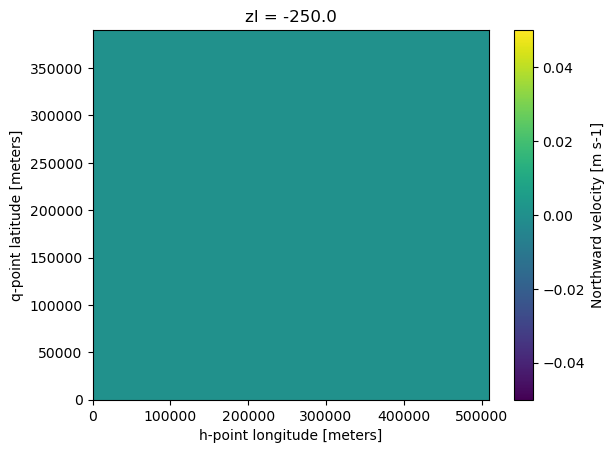

In [29]:
vel_file.v.isel(zl=0).plot()

In [30]:
eta_file = xr.open_dataset('/scratch/nm03/ae7501/mom6_input_directories/idealized/test0001/INPUT/init_eta.nc')

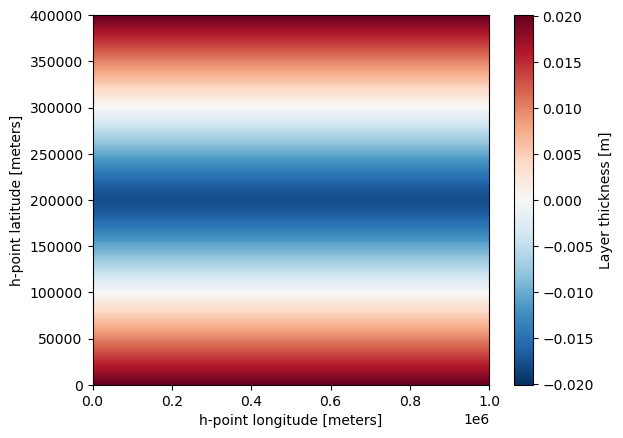

In [8]:
eta_file.eta_t.plot()